In [3]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/drive/MyDrive/NN_project/data.zip /content/
!cp /content/drive/MyDrive/NN_project/src.zip /content/
!cp /content/drive/MyDrive/NN_project/scripts.zip /content/

!unzip -q /content/data.zip -d /content/
!unzip -q /content/src.zip -d /content/
!unzip -q /content/scripts.zip -d /content/



Mounted at /content/drive


In [1]:
import sys
import os
import torch
import numpy as np
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt

sys.path.append('/content/')

from src.datasets.dataset import PKLotDataset, collate_fn
from src.models.custom_detector import get_custom_detector



def get_transform():
    return v2.Compose([
        v2.ToImage(),
        # Zmniejszamy zdjęcia do połowy rozmiaru
        v2.Resize(size=(360, 640), antialias=True),
        v2.ToDtype(torch.float32, scale=True),
    ])



def train_model(model, EPOCHS, transform, subset_size, id, val_subset, device):
    full_train_dataset = PKLotDataset(
        root_dir="/content/data/raw/train",
        annotation_file="/content/data/raw/train/_annotations.coco.json",
        transforms=transform()
    )
    train_subset_size = min(subset_size, len(full_train_dataset))
    train_indices = np.random.choice(len(full_train_dataset), train_subset_size, replace=False)
    train_dataset = Subset(full_train_dataset, train_indices)

    train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True,
        num_workers=2,
        collate_fn=collate_fn
    )

    full_val_dataset = PKLotDataset(
        root_dir="/content/data/raw/valid",
        annotation_file="/content/data/raw/valid/_annotations.coco.json",
        transforms=transform()
    )
    val_subset_size = min(val_subset, len(full_val_dataset))
    val_indices = np.random.choice(len(full_val_dataset), val_subset_size, replace=False)
    val_dataset = Subset(full_val_dataset, val_indices)

    val_loader = DataLoader(
        val_dataset,
        batch_size=16,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn
    )

    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=0.0005, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    train_losses = []
    val_losses = []

    print("Rozpoczynam trening i walidację...")
    for epoch in range(EPOCHS):

        model.train()
        epoch_train_loss = 0
        train_bar = tqdm(train_loader, desc=f"Epoka {epoch+1}/{EPOCHS} [Train]")

        for images, targets in train_bar:
            images = list(image.to(device) for image in images)
            fixed_targets = []
            for t in targets:
                t_dict = {}
                for k, v in t.items():
                    if k == "boxes" and v.numel() == 0:
                        t_dict[k] = torch.empty((0, 4), dtype=torch.float32, device=device)
                    else:
                        t_dict[k] = v.to(device)
                fixed_targets.append(t_dict)
            targets = fixed_targets

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            epoch_train_loss += losses.item()
            train_bar.set_postfix({'loss': losses.item()})

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        epoch_val_loss = 0
        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f"Epoka {epoch+1}/{EPOCHS} [Valid]")
            for images, targets in val_bar:
                images = list(image.to(device) for image in images)
                fixed_targets = []
                for t in targets:
                    t_dict = {}
                    for k, v in t.items():
                        if k == "boxes" and v.numel() == 0:
                            t_dict[k] = torch.empty((0, 4), dtype=torch.float32, device=device)
                        else:
                            t_dict[k] = v.to(device)
                    fixed_targets.append(t_dict)
                targets = fixed_targets

                val_loss_dict = model(images, targets)
                val_batch_losses = sum(loss for loss in val_loss_dict.values())

                epoch_val_loss += val_batch_losses.item()
                val_bar.set_postfix({'val_loss': val_batch_losses.item()})

        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        lr_scheduler.step()
        print(f"Średnia strata: Train = {avg_train_loss:.4f} | Valid = {avg_val_loss:.4f}")

    os.makedirs('/content/checkpoints', exist_ok=True)
    torch.save(model.state_dict(), f'/content/checkpoints/custom_model_subset{id}.pth')

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', marker='o', linewidth=2)
    plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Loss', marker='o', linewidth=2)
    plt.title('Spadek straty (Loss) w trakcie treningu i walidacji')
    plt.xlabel('Epoka')
    plt.ylabel('Wartość Loss')
    plt.xticks(range(1, EPOCHS + 1))
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

ModuleNotFoundError: No module named 'src'

Rozpoczynam trening i walidację...


Epoka 1/25 [Valid]: 100%|██████████| 7/7 [00:04<00:00,  1.66it/s, val_loss=19.2]


Średnia strata: Train = 19.0024 | Valid = 18.2366


Epoka 2/25 [Valid]: 100%|██████████| 7/7 [00:03<00:00,  1.86it/s, val_loss=17.3]


Średnia strata: Train = 17.0912 | Valid = 16.4041


...

Średnia strata: Train = 9.4069 | Valid = 9.9842


Epoka 24/25 [Valid]: 100%|██████████| 7/7 [00:04<00:00,  1.67it/s, val_loss=9.31]


Średnia strata: Train = 9.5331 | Valid = 9.8191


Epoka 25/25 [Valid]: 100%|██████████| 7/7 [00:04<00:00,  1.62it/s, val_loss=9.63]


Średnia strata: Train = 9.4593 | Valid = 9.8832


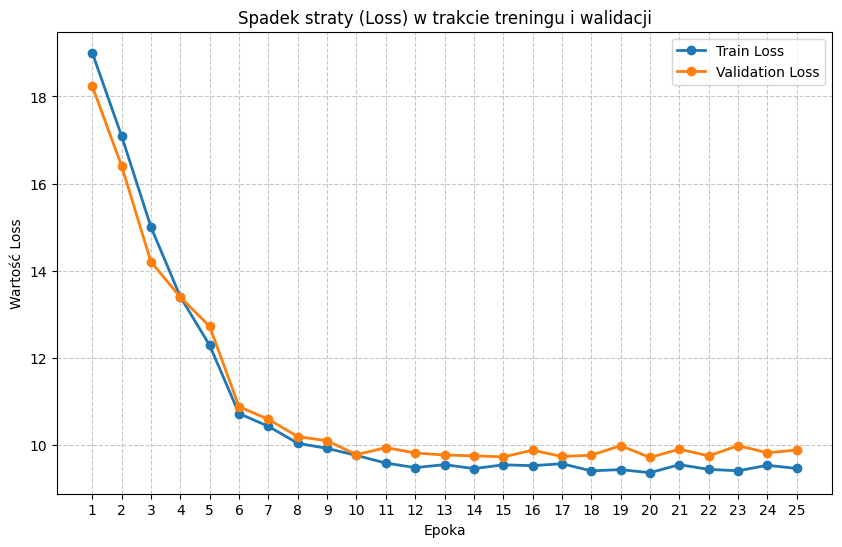

In [ ]:
model1 = get_custom_detector(num_classes=3)

train_model(model1, 25, get_transform, 1000, "1", 100)

!cp /content/checkpoints/custom_model_subset1.pth /content/drive/MyDrive/NN_project

In [8]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.6 MB/s eta 0:00:00


In [14]:
import sys
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchvision.transforms import v2
from torchmetrics.detection.mean_ap import MeanAveragePrecision

sys.path.append('/content/')
from src.datasets.dataset import PKLotDataset, collate_fn
from src.models.custom_detector import get_custom_detector

def evaluate_model(model, transform, id, device):
    test_dataset = PKLotDataset(
        root_dir="/content/data/raw/test",
        annotation_file="/content/data/raw/test/_annotations.coco.json",
        transforms=transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn
    )

    model.load_state_dict(torch.load(f'/content/drive/MyDrive/NN_project/custom_model_subset{id}.pth', map_location=device, weights_only=True))
    model.to(device)

    model.eval()

    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)

    print(f"Rozpoczynam ewaluację")

    with torch.no_grad():
        progress_bar = tqdm(test_loader, desc="Ewaluacja")

        for images, targets in progress_bar:
            images = list(image.to(device) for image in images)

            fixed_targets = []
            for t in targets:
                t_dict = {}
                for k, v in t.items():
                    if k == "boxes" and v.numel() == 0:
                        t_dict[k] = torch.empty((0, 4), dtype=torch.float32, device=device)
                    else:
                        t_dict[k] = v.to(device)
                fixed_targets.append(t_dict)

            predictions = model(images)

            metric.update(predictions, fixed_targets)

    results = metric.compute()

    print("-" * 50)
    print("WYNIKI EWALUACJI:")
    print("-" * 50)
    print(f"mAP@50-95:    {results['map'].item():.4f}")
    print(f"mAP@50:       {results['map_50'].item():.4f}")
    print(f"mAP@75:       {results['map_75'].item():.4f}")
    print(f"Recall (MAR): {results['mar_100'].item():.4f}")
    print("-" * 50)

In [ ]:
transform = v2.Compose([
    v2.ToImage(),
    v2.Resize(size=(360, 640), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
])
# model1 = get_custom_detector(num_classes=3)
evaluate_model(model1, transform, 1)

Używane urządzenie: cuda
Rozpoczynam ewaluację


Ewaluacja: 100%|██████████| 39/39 [00:41<00:00,  1.05s/it]


--------------------------------------------------
WYNIKI EWALUACJI:
--------------------------------------------------
mAP@50-95:    0.0495
mAP@50:       0.1400
mAP@75:       0.0252
Recall (MAR): 0.0949
--------------------------------------------------


In [ ]:
# Augmentacje

from src.models.custom_detector2 import get_custom_detector2

def get_transform_augment(is_train=True):
    transforms = [
        v2.ToImage(),
        v2.Resize(size=(360, 640), antialias=True),
    ]

    if is_train:
        transforms.extend([
            # Losowe poziome odbicie zdjęcia
            v2.RandomHorizontalFlip(p=0.5),
            # Delikatna zmiana jasności, kontrastu i nasycenia
            v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
        ])

    transforms.append(v2.ToDtype(torch.float32, scale=True))
    return v2.Compose(transforms)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Używane urządzenie: {device}")

model2 = get_custom_detector2(num_classes=3)

train_model(model2, 25, get_transform_augment, 1000, "2", 100, device)


Używane urządzenie: cpu
Rozpoczynam trening i walidację...


Epoka 1/25 [Train]:   0%|          | 0/63 [00:00<?, ?it/s]Exception ignored in: <function _releaseLock at 0x7acc3d6cd260>
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 243, in _releaseLock
    def _releaseLock():
    
KeyboardInterrupt: 
